In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten


In [2]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
#now we have to convert this 0 to 255 pixels value into 0 to 1 range
X_train=X_train/255
X_test=X_test/255

In [4]:
X_test.shape

(10000, 28, 28)

In [5]:
X_train[0].shape

(28, 28)

In [11]:
model=Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam')

In [15]:
history=model.fit(X_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0143 - val_loss: 0.0928
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0109 - val_loss: 0.0968
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0095 - val_loss: 0.0988
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0080 - val_loss: 0.1075
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0085 - val_loss: 0.1072
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0065 - val_loss: 0.1146
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0050 - val_loss: 0.0992
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0058 - val_loss: 0.1092
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0079 - val_loss: 0.1175
Epoch 10/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.0046 - val_loss: 0.1148


In [18]:
y_pred=model.predict(X_test)
y_pred
y_prob=y_pred.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [21]:
y_prob

array([7, 2, 1, ..., 4, 5, 6])

In [24]:
print(type(y_test))
print(type(y_pred))

print(y_test.shape)
print(y_pred.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(10000,)
(10000, 10)


In [25]:
import numpy as np

y_pred = np.argmax(y_pred, axis=1)

In [22]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [26]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9778

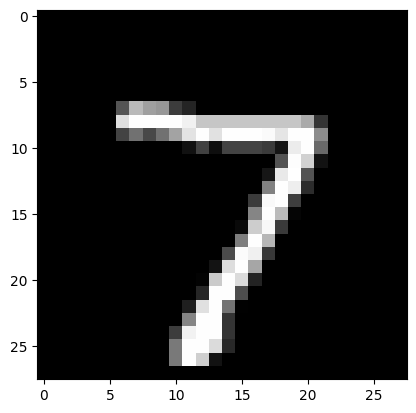

In [27]:
import matplotlib.pyplot as plt

plt.imshow(X_test[0], cmap='gray')
plt.show()

In [33]:
sample=X_test[123].reshape(1,28,28)
prediction=model.predict(sample)
import numpy as np
digit=np.argmax(prediction)
print("predicted ",digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
predicted  6


Enter image index (0-9999): 234


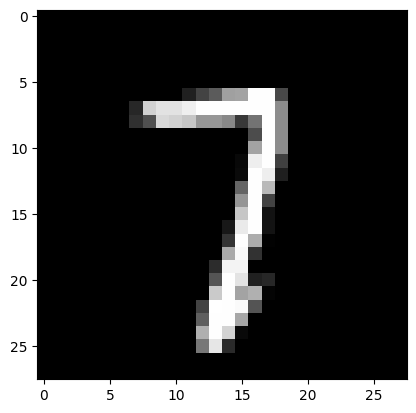

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted: 7
Actual: 7


In [35]:
index = int(input("Enter image index (0-9999): "))

plt.imshow(X_test[index], cmap='gray')
plt.show()

prediction = model.predict(X_test[index].reshape(1,28,28))

print("Predicted:", np.argmax(prediction))
print("Actual:", y_test[index])

In [36]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [37]:
img = Image.open("5.png")   # <-- apna image path likhna

In [38]:
img = img.convert("L")

In [39]:
img = img.resize((28,28))

In [40]:
img = np.array(img)

In [41]:
img = 255 - img

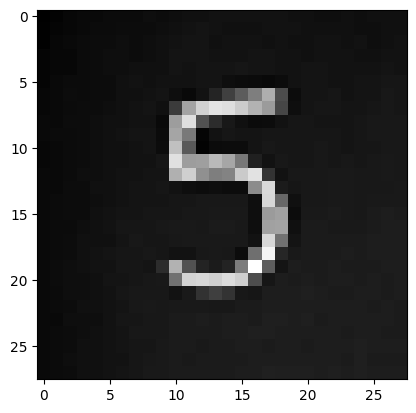

In [43]:
plt.imshow(img, cmap='gray')
plt.show()

In [42]:
img = img / 255.0

In [45]:
img = img.reshape(1,28,28)
prediction = model.predict(img, verbose=0)

print("Predicted Digit:", np.argmax(prediction))
print("Probabilities:", prediction)

Predicted Digit: 7
Probabilities: [[3.9215684e-09 2.8393352e-09 4.0927300e-01 1.1301015e-01 5.8179003e-23
  8.9495806e-03 1.5053763e-05 4.6874920e-01 3.0469482e-06 2.3920057e-08]]


In [48]:
from google.colab import files

files.download("mnist_ann.keras")
doem

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
model.save("mnist_ann.keras")

In [46]:
model.save("mnist_ann.keras")